# Aula 2 — Análise Exploratória, Parte 1

> **Data:** *(03/09/2026)*  
> **Professor(a):** *(Felipe Aldrighi e Sofia Sayuri)*

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Limpeza e tratamento dos dados

Para esta aula, utilizaremos a base de dados do **Titanic**! Essa base tem dados sobre os passageiros do famoso transatlântico, incluindo a informação de que sobreviveram ou não, e é um case de estudo famoso na comunidade de Ciência de Dados.

**Dicionário - Titanic DataSet**

- `PassengerId`: Código de identificação do passageiro;
- `Survived`: Se sobreviveu (survived=1) ou não (survived=0);
- `Pclass`: Classe comercial. Pode ser primeira (Pclass=1), segunda (Pclass=2) ou terceira classe (Pclass=3);
- `Name`: Nome do passageiro;
- `Sex`: Sexo biológico;
- `Age`: Idade;
- `SibSp`: Número de irmãos;
- `Parch`: Representa o número de pais ou crianças que o passageiro tinha consigo a bordo;
- `Ticket`: Número do ticket;
- `Fare`: Valor pago pelo ticker;
- `Cabin`: Cabine onde ficou hospedado;
- `Embarked`: Local onde embarcou (C = Cherbourg; Q = Queenstown; S = Southampton).

In [139]:
import shutil
import urllib.request
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Na primeira vez a base é baixada para data_raw/ (o original, que fica de
# referência) e copiada para data/ (a cópia de trabalho, que é a que vamos usar).
# Bagunçou a base? Apague data/titanic.csv e rode esta célula de novo.
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
Path('data_raw').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)

if not Path('data_raw/titanic.csv').exists():
    print('Baixando titanic.csv...')
    urllib.request.urlretrieve(url, 'data_raw/titanic.csv')
if not Path('data/titanic.csv').exists():
    shutil.copy('data_raw/titanic.csv', 'data/titanic.csv')

df = pd.read_csv('data/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [140]:
# Seu código aqui


Na aula anterior, estudamos sobre limpeza e tratamento de dados. Portanto, que tal aplicar seus conhecimentos fazendo a limpeza desta base de dados?

**Agora é com você! Faça a limpeza do Titanic Dataset!**

## 2. Entendendo tipos de variáveis

### 2.1. Variáveis Qualitativas (Categóricas)

São variáveis que representam grupos ou categorias. Têm valor descritivo, mas não necessariamente matemático.

#### Nominais

Representam rótulos; não possuem ordem.

**Exemplos:** 

- Raça (Branco, Preto, Pardo, etc.);
- Cidade; etc.

**Pergunta:** Há variáveis categórias nominais na nossa base? Se sim, quais?

#### Ordinais

Possuem uma ordem; um senso de progressão, mas não possuem dimensão matemática real.

**Exemplos:** 

- Escolaridade (Ensino Fundamental, Médio, Superior);
- Planos na Netflix (Padrão com anúncios, Padrão sem anúncios, Premium); etc.

**Pergunta:** Há variáveis categóricas ordinais na nossa base? Se sim, quais?

**Pergunta:** Faz sentido calcular a média de uma variável qualitativa? E fazer uma contagem de possíveis valores?

### 2.2. Variáveis Quantitativas

Representam medidas numéricas reais.

#### Discretas

São valores inteiros contáveis.

**Exemplos:**

- Número de filhos;
- Quantidade de itens numa compra.

**Pergunta:** Há variáveis quantitativas discretas na nossa base de dados? Se sim, quais?

#### Contínuas

São valores pertencentes ao conjunto dos reais. Podem assumir qualquer valor dentro de um intervalo.

**Exemplos:**

- Altura;
- Renda;

**Pergunta:** Há variáveis quantitativas discretas na nossa base de dados? Se sim, quais?

**Pergunta:** Faz sentido calcular a média de uma variável quantitativa? E fazer uma contagem de possíveis valores?

## 3. Estatística descritiva

### 3.1. Contagem e frequência

Entender a quantidade de valores em cada categoria de dados é uma etapa relevante para entender sua representatividade e balanceamento dentro da base de dados - evitando que as análises reproduzam um potencial viés existente na base de dados.

Para fazer a contagem de valores, o Pandas possui o comando `value_counts`:

In [141]:
# Seu código aqui
#df.dtypes

print(df['Sex'].value_counts())
print(df['Survived'].value_counts())

Sex
male      266
female    152
Name: count, dtype: int64
Survived
0    266
1    152
Name: count, dtype: int64


In [142]:
# Passo 1 - diagnóstico: antes de mexer em qualquer coisa, entender o que temos.
df.info()

# Quantos valores nulos existem por coluna, em quantidade e em porcentagem?
nulos = pd.DataFrame({
    'nulos': df.isna().sum(),
    '%': (df.isna().mean() * 100).round(1),
})
nulos[nulos['nulos'] > 0]

# Linhas repetidas inteiras e IDs repetidos
print('Linhas duplicadas:', df.duplicated().sum())
print('PassengerId repetidos:', df['PassengerId'].duplicated().sum())

# Passo 2 - tratamento

# Cabin: 687 nulos (77% da base). Preencher seria inventar dado, então removemos a coluna.
df = df.drop(columns=['Cabin'])

# Age: 177 nulos (20%). É muito para simplesmente descartar as linhas, então imputamos.
# Usamos a MEDIANA por classe e sexo (e não a média geral): a idade típica muda bastante
# entre esses grupos, e a mediana sofre menos com valores extremos.
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

# Embarked: apenas 2 nulos. Preenchemos com a moda ('S', Southampton).
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Padronização de texto: remove espaços sobrando nas colunas de texto.
for col in ['Name', 'Sex', 'Ticket', 'Embarked']:
    df[col] = df[col].str.strip()

df.isna().sum()

# Passo 3 - conferência
print('Formato final:', df.shape)
print('Total de nulos:', df.isna().sum().sum())

# Último olhar nos valores estranhos que sobraram. Não vamos removê-los: tarifa zero
# provavelmente é cortesia/tripulação e a tarifa de 512 é real (1a classe), mas é bom
# saber que eles existem antes de olhar qualquer média.
print('Tarifas iguais a zero:', (df['Fare'] == 0).sum())
print('Idade mínima e máxima:', df['Age'].min(), '-', df['Age'].max())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 56.1 KB
Linhas duplicadas: 0
PassengerId repetidos: 0
Formato final: (418, 11)
Total de nulos: 1
Tarifas iguais a zero: 2
Idade mínima e máxima: 0.17 - 76.0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [143]:
# Seu código aqui
#df.dtypes

print(df['Sex'].value_counts())


Sex
male      266
female    152
Name: count, dtype: int64


Valores brutos podem ser difíceis de interpretar, pricipalmente se forem muito grandes. Portanto, pode ser conveniente avaliar a **frequência** com que determinadas categorias aparecem - isto é, a quantidade de ocorrências em relação ao total.

In [144]:
# Seu código aqui


A **frequência** normalmente terá valores de 0 a 1. Porém podemos transformar isso em percentual multiplicando por 100!

In [145]:
# Seu código aqui


Há mais homens do que mulheres na nossa base. Como isso pode impactar a nossa análise?

### 3.2. Distribuição: Média, mediana e quartis

São estatísticas quantitativas que ajudam a posicionar dados quantitativos de maneira relativa, de forma a entender sua distribuição.

**Quartis**

Representam os valores limítrofes de faixas de distribuição que contém exatamente 1/4 da quantidade total de elementos (por isso o nome). São utilizados para entender em que faixas de valores os elementos estão concentrados. Por exemplo, na distribuição fictícia abaixo:

- Mínimo = 0.00
- Q1 (25%) = 0.50 -> Valor mais alto entre os 25% valores mais baixos
- Q2 (50%) = 0.63 -> Valor mais alto entre os 50% valores mais baixos
- Q3 (75%) = 0.77 -> Valor mais alto entre os 75% valores mais baixos
- Máximo/Q4 (100%) = 1.00 -> Valor mais alto entre os 100% valores mais baixos

<Axes: ylabel='Frequency'>

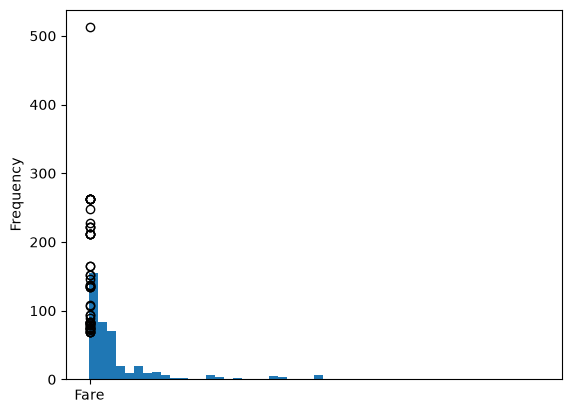

In [146]:
# Quartis
df['Fare'].quantile([0.25,0.5,0.75])
df['Fare'].plot.hist(bins = 50)
df['Fare'].plot.box()


**Pergunta:** O que podemos afirmar sobre a distribuição dos valores na situação ilustrada?

**Mediana:**

É o valor que fica na posição central de uma lista ordenada de valores. Por exemplo, na lista [1, 2, 3, 4, 5], a mediana é o '3'. É também representada pelo quartil Q3 (50%).
Por ser o valor central, nos ajuda a estabelecer se qualquer valor analisado está entre os 50% mais altos ou entre os 50% mais baixos do conjunto universo de elementos, proporcionando um senso relativo de distribuição.

In [147]:
# Mediana
df['Fare'].median()

np.float64(14.4542)

In [148]:
# Também a mediana
df['Fare'].quantile(0.5)

np.float64(14.4542)

**Média:**

Representa a razão entre a soma dos valores e a quantidade de elementos. É uma maneira de metrificar o quão "pesados" os dados são em relação a si mesmos, comumente de maneira comparativa à mediana.

In [149]:
# Média
df['Fare'].mean()

np.float64(35.627188489208635)

Por exemplo, **o que significa quando a média é maior que a mediana? E quando é mais baixa?**

No Pandas, essas métricas podem ser observadas individualmente, porém o comando `describe` traz uma combinação de todas elas.

In [150]:
# Seu código aqui
df['Fare'].describe().to_frame().transpose()

,count,mean,std,min,25%,50%,75%,max
Fare,417.0,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292


**Pergunta:** O que você consegue inferir sobre a variável `Fare` analisando somente os resultados acima?

## 4. Agregações e métricas agregadas

Analisar variáveis de maneira isolada pode ser útil para entender balanceamento, representatividade, distribuições e até mesmo identificar outliers. Contudo, em uma análise aprofundada, queremos ser capazes de entender também como determinados parâmetros se comportam em relação a outros. Neste sentido, as **agregações** possibilitam que observemos de maneira simultânea um grupo de parâmetros.

### 4.1. Agrupamentos

Úteis principalmente quando precisamos analisar a relação entre variáveis qualitativas e quantitativas.

Imagine que, enquanto investigamos o dataset em questão, a seguinte pergunta apareça: **Como a taxa de sobrevivência se relaciona com os sexo biológico dos passageiros?**

Podemos usar o comando `groupby` para agrupar a média de sobrevivência por sexo e descobrir:

In [158]:
# taxa de sobrevivência por sexo
df.groupby('Sex')['Survived'].mean().reset_index(name='survival_rate')

,Sex,survival_rate
0,female,1.0
1,male,0.0


É possível agrupar métricas de variáveis quantitativas por múltiplas variáveis qualitativas, como no exemplo abaixo:

In [159]:
# média de idade por classe e sexo
df.groupby(['Pclass','Sex'])['Age'].mean().unstack()

Sex,female,male
Pclass,,
1,41.320000,40.701754
2,24.364000,30.753968
3,22.745417,24.345274


Também é possível aggregar múltiplas métricas de variáveis quantitativas em relação à variáveis qualitativas. Porém, para isso, é necessário utilizar o comand `agg`.

In [162]:
# Seu código aqui
df.groupby('Pclass').agg(
    passengers= ('PassengerId','count'),
    avg_age = ('Age','mean'),
    median_fare = ('Fare','median')
).reset_index() 

,Pclass,passengers,avg_age,median_fare
0,1,107,40.990654,60.0000
1,2,93,28.692688,15.7500
2,3,218,23.816881,7.8958


**Exercício: Descubra a taxa média de sobrevivência por local de embarque e classe comercial**

In [172]:
# Escreva seu código aqui
df.groupby(['Embarked','Pclass'])['Survived'].mean().unstack().reset_index().round(3)

Pclass,Embarked,1,2,3
0,C,0.50,0.364,0.229
1,Q,1.00,0.000,0.561
2,S,0.42,0.333,0.289


### 4.2. Tabelas cruzadas

Quando queremos verificar a frequência relativa entre categorias específicas de duas ou mais variáveis qualitativas, as **tabelas cruzadas** são a melhor opção.

Por exemplo, se quisermos saber a contagem de pessoas que havia em cada classe comercial por gênero:

In [178]:
# Seu código aqui
pd.crosstab(df['Pclass'],df['Sex'],margins = True).reset_index()


Sex,Pclass,female,male,All
0,1,50,57,107
1,2,30,63,93
2,3,72,146,218
3,All,152,266,418


Também é possível observar a frequência relativa de acordo com o índice (nesse caso a classe comercial):

In [176]:
# Seu código aqui
pd.crosstab(df['Pclass'],df['Sex'],margins = True,normalize='index').reset_index()

Sex,Pclass,female,male
0,1,0.467290,0.532710
1,2,0.322581,0.677419
2,3,0.330275,0.669725
3,All,0.363636,0.636364


**Pergunta:** O que você consegue inferir a partir da análise de frequência de gênero por classe comercial?

### 4.3. Correlações

A **correlação** é uma métrica de influência entre variáveis quantitativas. Valores próximos de 1 indicam que as variáveis têm **correlação positiva**, isto é, elas se influenciam de maneira proporcional (crescem juntas e decrescem juntas). Valores próximos de -1 indicam **correlação negativa**, isto é, elas se influenciam de maneira insamente proporcional (enquanto uma cresce, a outra decresce). Já valores próximos de 0 indicam que as variáveis têm pouca influência uma sobre a outra.

In [179]:
# Seu código aqui
df[['Age','Fare','Survived']].corr()

,Age,Fare,Survived
Age,1.000000,0.353408,-0.007134
Fare,0.353408,1.000000,0.191514
Survived,-0.007134,0.191514,1.000000


**Pergunta:** O que é possível dizer a partir da correlação entre as colunas `Age`, `Fare` e `Survived`?